In [ ]:
import pinocchio as pin
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from pinocchio.visualize import MeshcatVisualizer
import time
import os

# URDF Import
Current_File = os.getcwd()
URDF_Package_Path = os.path.join(Current_File, "GIT_CAO")
URDF_File = os.path.join(
    URDF_Package_Path, 
    "Assemblage_GIT", 
    "urdf", 
    "Assemblage_GIT.urdf"
)

# Model creation

model, collision_model, visual_model = pin.buildModelsFromUrdf(URDF_File, URDF_Package_Path)
data = model.createData()

In [ ]:
# Initialisation of Meshcat visualization

viz = MeshcatVisualizer(model, collision_model, visual_model)
viz.initViewer(open=True)
viz.loadViewerModel()
q = pin.neutral(model)
viz.display(q)

You can open the visualizer by visiting the following URL:
http://127.0.0.1:7000/static/


In [ ]:
# Manual command
Prismatic = 0
Joint_1 = 0
Joint_2 = 0
Joint_3 = 0
Joint_4 = 0
Joint_5 = 0
Joint_6 = 0

q[0] = -Prismatic           # Prismatic Joint: Movement in meters
q[1] = np.deg2rad(Joint_1)  # Joint_1 : Rotation in radians
q[2] = np.deg2rad(Joint_2)  # Joint_2 : Rotation in radians
q[3] = np.deg2rad(Joint_3)  # Joint_3 : Rotation in radians
q[4] = np.deg2rad(Joint_4)  # Joint_4 : Rotation in radians
q[5] = np.deg2rad(Joint_5)  # Joint_5 : Rotation in radians
q[6] = np.deg2rad(Joint_6)  # Joint_6 : Rotation in radians

viz.display(q)

In [ ]:
from scipy.signal import savgol_filter

# Parsing of RoboDK files and filtering 

# ----------------------------------------------------------------------
df = pd.read_json('P1COR0G1_Positions.json')   # Enter the file name here
# ----------------------------------------------------------------------

columns = ['J1', 'J2', 'J3', 'J4', 'J5', 'J6', 'J7']
df_positions = df[columns]

# Parameters of Savitzky-Golay filter to smooth the data
window_size = 51
polynomial_order = 3


df_positions_smoothed = df_positions.copy()
for col in columns:
    df_positions_smoothed[col] = savgol_filter(df_positions[col], window_length=window_size, polyorder=polynomial_order)

# Create Excel files to verify the data parsing
#df_positions_smoothed.to_excel('Positions_Axes.xlsx',  index=False)

In [ ]:
# Play the simulation in Meshcat
dt = 0.0000005

for index, row in df_positions_smoothed.iterrows():
    # Extract values from the DataFrame
    J1 = row['J1']
    J2 = row['J2']
    J3 = row['J3']
    J4 = row['J4']
    J5 = row['J5']
    J6 = row['J6']
    J7 = row['J7']
    
    q[0] = (J7 / 1000.0) 
    q[1] = np.deg2rad(J1)
    q[2] = np.deg2rad(J2) + np.deg2rad(0)
    q[3] = np.deg2rad(J3) + np.deg2rad(-90)
    q[4] = np.deg2rad(J4)
    q[5] = np.deg2rad(J5)
    q[6] = np.deg2rad(J6)
    
    
    viz.display(q)
    time.sleep(dt)

print("Simulation finished.")

Simulation finished.


In [ ]:
# Initialize arrays for joint states
q_prev = np.zeros(model.nq)
v_prev = np.zeros(model.nv)

# Create a history log for torque visualization
torque_history = []

time_step = 0.01
for index, row in df_positions_smoothed.iterrows():
    J1 = row['J1']
    J2 = row['J2']
    J3 = row['J3']
    J4 = row['J4']
    J5 = row['J5']
    J6 = row['J6']
    J7 = row['J7']
    
    # Calculate joint positions (offsets added to align Python and RoboDK initial configurations)
    q[0] = (J7 / 1000.0) 
    q[1] = np.deg2rad(J1)
    q[2] = np.deg2rad(J2) + np.deg2rad(90)
    q[3] = np.deg2rad(J3) + np.deg2rad(-90)
    q[4] = np.deg2rad(J4)
    q[5] = -np.deg2rad(J5)
    q[6] = np.deg2rad(J6)
    
    # Velocity and acceleration calculations
    if index == 0:
        v = np.zeros(model.nv)
        a = np.zeros(model.nv)
    else:
        v = (q - q_prev) / time_step
        a = (v - v_prev) / time_step
        
    # Dynamics computation using RNEA (Recursive Newton-Euler Algorithm)
    tau = pin.rnea(model, data, q, v, a)

    # Account for the hydraulic pump on the 2nd joint
    tau_corrected = np.copy(tau)
    tau_corrected[2] = tau[2] * 0.2
    
    torque_history.append(np.copy(tau_corrected))
    
    # Update
    q_prev = np.copy(q)
    v_prev = np.copy(v)


torques_table = np.array(torque_history)

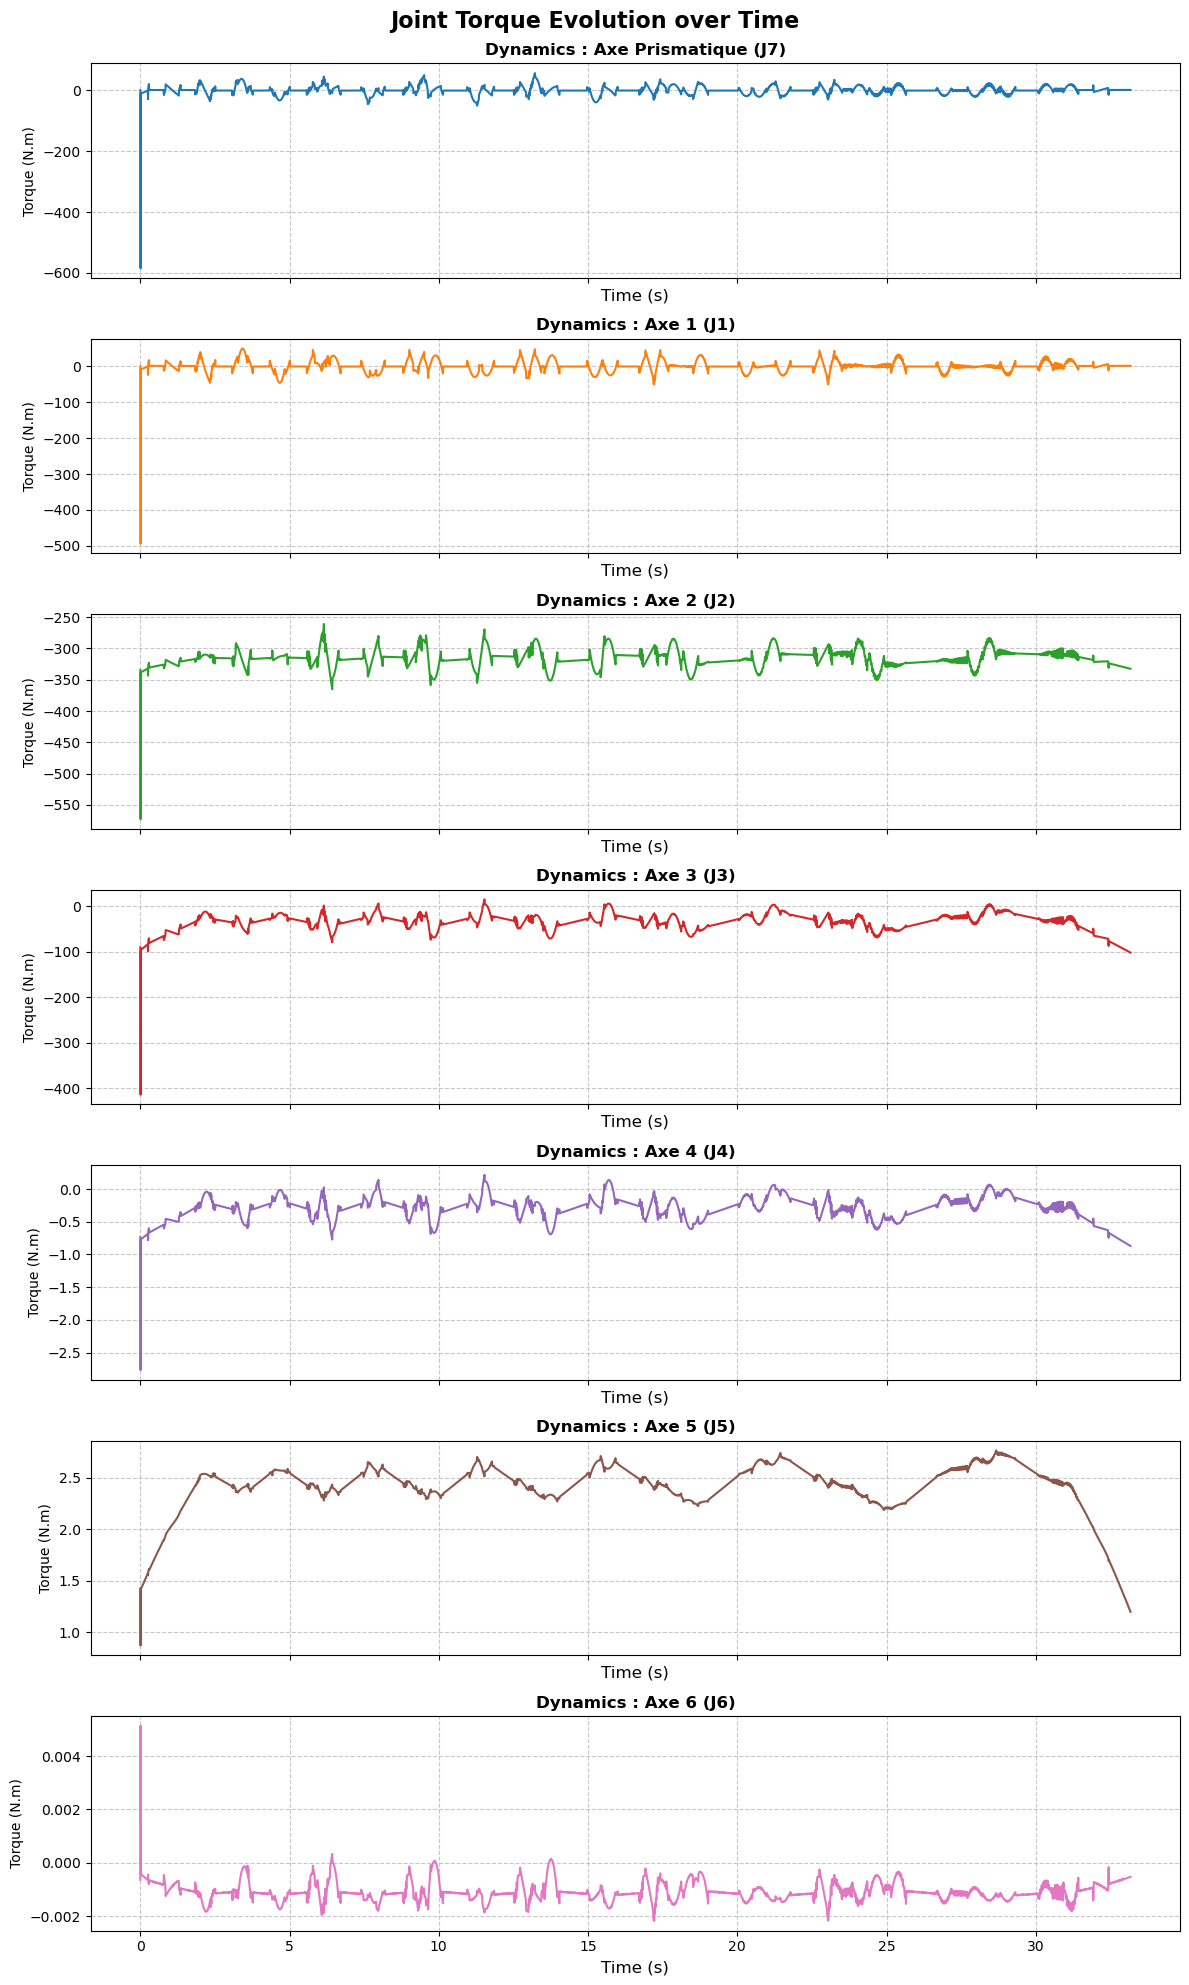

In [ ]:
nb_points = torques_table.shape[0]
time = np.arange(nb_points) * time_step

# Axes's names
joint_names = [
    'Axe Prismatique (J7)', 
    'Axe 1 (J1)', 
    'Axe 2 (J2)', 
    'Axe 3 (J3)', 
    'Axe 4 (J4)', 
    'Axe 5 (J5)', 
    'Axe 6 (J6)'
]

# Plot's creation
figure, axes = plt.subplots(7, 1, figsize=(12, 20), sharex=True)

# 3. Graphs
for i in range(7):
    # Add of colors
    axes[i].plot(time, torques_table[:, i], linewidth=1.5, color=f'C{i}')
    
    # Titles
    axes[i].set_title(f"Dynamics : {joint_names[i]}", fontsize=12, fontweight='bold')
    
    # Units
    axes[i].set_ylabel("Torque (N.m)", fontsize=10)
    axes[i].set_xlabel("Time (s)", fontsize=12) 
        
    # Grid
    axes[i].grid(True, linestyle='--', alpha=0.7)


# Global title
figure.suptitle("Joint Torque Evolution over Time", fontsize=16, fontweight='bold', y=0.99)


plt.tight_layout() 
plt.show()

In [ ]:
import numpy as np

print("--- Torque Statistics (Tau) for each joint (in N.m) ---\n")

for i in range(len(joint_names)):
    # Retrieve data for joint i
    joint_torques = torques_table[:, i]
    
    # Calculations
    tau_moy = np.mean(joint_torques)
    tau_min = np.min(joint_torques)
    tau_max = np.max(joint_torques)
    
   # Display results
    print(f"{joint_names[i]} :")
    print(f"  -> Mean : {tau_moy:.4f}")
    print(f"  -> Minimum : {tau_min:.4f}")
    print(f"  -> Maximum : {tau_max:.4f}")
    print("-" * 40)